<div
  style="
    background-color: #f0f0f0;
    color:rgb(56, 56, 56);
    padding: 8px;
    display: flex;
    align-items: center;
    gap: 100px;
  "
>
  <img src="https://github.com/Angel-ISO/Deeplearning/blob/main/week1/images/brand.svg?raw=1" style="max-height: 80px;">
  <strong>
    AI Saga: Deep Learning & Generative AI</br>
    1.Lab Building a Multi-Layer Perceptron from Scratch for Wine Quality Classification</br>
  </strong>
  <emph>
    Student Name: Angel Iso</br>
    Date: 2026-04-28</br>
  </emph>
</div>

### Background

You will be working with the **Wine Quality Dataset**, which contains physicochemical measurements of Portuguese "Vinho Verde" wines.

Each wine sample is rated by experts on a quality scale from 3 to 9. Your task is to build a custom multi-layer perceptron (MLP) using PyTorch to classify wines into **three quality categories**:

- **Low Quality**: scores 3-5 (below average wines)
- **Medium Quality**: scores 6-7 (average wines)
- **High Quality**: scores 8-9 (premium wines)

---

### Description

Check LMS for the last updated instructions.

Don't forget to **convert** the actual dataset into a 3-class one.

---

### Deliverables

Complete the Jupyter Notebook file named **1.lab.1-wine-quality-mlp.ipynb**.

#### Requirements

- Use **PyTorch** high-level libraries
- Code must be well-commented and clearly organized
- Include markdown cells explaining each step and your design decisions
- You can use Google Colab and their free-tier GPU

---

### Key Reminders

**Think before implementing your MLP class** - consider the input/output dimensions, activation functions, and architectural choices carefully

**Present well-reasoned conclusions** - your analysis section should demonstrate deep understanding of your model's behavior and performance. **This last section is critical for demonstrating deep understanding.** Discuss:

- Which features appear most important for wine quality classification?
- How well does your model distinguish between the three quality classes?
- What challenges did you encounter?
- What architectural choices or hyperparameters had the most impact on performance?
- Suggestions for improvement

**Note**: All submitted code is code that you must be able to defend (even if AI generated!).

## configuración

Antes de empezar voy a importar todas las librerías que voy a necesitar a lo largo del notebook. Trabajo principalmente con **PyTorch** para construir mi MLP, **pandas** y **numpy** para el manejo de datos, **matplotlib** y **seaborn** para las visualizaciones y **scikit-learn** para el preprocesamiento (escalado, split) y para las métricas finales de evaluación.

También fijo las semillas de los generadores aleatorios para que mis experimentos sean reproducibles, y detecto si hay GPU disponible para mover el entrenamiento ahí cuando sea posible.

In [5]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

Using device: cpu


## Carga  de datos

Lo primero que hago es cargar el CSV con las mediciones fisicoquímicas de los vinos. Quiero ver cómo está estructurado el dataset, qué tipos de datos tiene cada columna y si hay valores faltantes que tenga que manejar.

La columna `Id` solo es un identificador y no aporta nada al modelo, así que la elimino de entrada.

In [6]:

url = "https://raw.githubusercontent.com/Angel-ISO/Deeplearning/refs/heads/main/week1/wine-quality-dataset.csv"
df = pd.read_csv(url)

if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1143, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [9]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nDuplicated rows: {df.duplicated().sum()}")

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicated rows: 125


### variable objetivo

La variable que quiero predecir es `quality`. Antes de transformarla a 3 clases voy a ver cómo se distribuye originalmente, porque esto me da una idea de qué tan desbalanceado va a quedar el problema.

/tmp/ipykernel_5022/2442307660.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis', ax=ax)


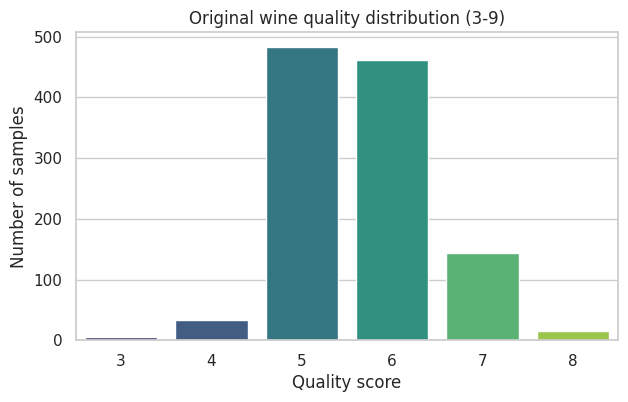

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(x='quality', data=df, palette='viridis', ax=ax)
ax.set_title('Original wine quality distribution (3-9)')
ax.set_xlabel('Quality score')
ax.set_ylabel('Number of samples')
plt.show()

print(df['quality'].value_counts().sort_index())

### calidad a 3 clases

Según las instrucciones, tengo que transformar la calidad numérica a 3 clases:

- **0 — Low**: 3, 4, 5
- **1 — Medium**: 6, 7
- **2 — High**: 8, 9

Hago esto con una función `map` simple para tener control total sobre el mapeo.

/tmp/ipykernel_5022/4236579459.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality_class', data=df, palette='magma', ax=ax)
/tmp/ipykernel_5022/4236579459.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names)


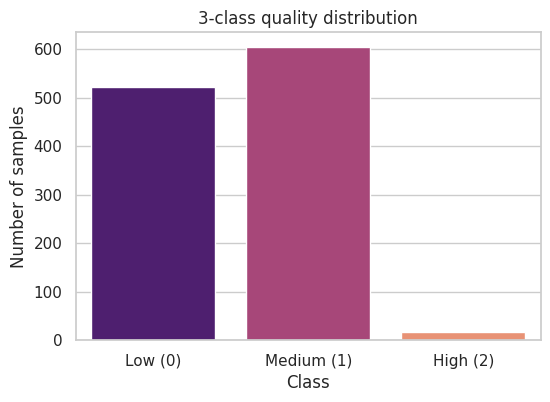

quality_class
0    522
1    605
2     16
Name: count, dtype: int64


In [11]:
def quality_to_class(q):
    if q <= 5:
        return 0
    elif q <= 7:
        return 1
    else:
        return 2

df['quality_class'] = df['quality'].apply(quality_to_class)

class_names = ['Low (0)', 'Medium (1)', 'High (2)']
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='quality_class', data=df, palette='magma', ax=ax)
ax.set_xticklabels(class_names)
ax.set_title('3-class quality distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Number of samples')
plt.show()

print(df['quality_class'].value_counts().sort_index())

Como ya se ve, la clase **High** queda muy minoritaria respecto a las otras dos. Esto es un desbalance que voy a tener presente cuando interprete las métricas (la accuracy global puede ser engañosa) y cuando elija la función de pérdida (puedo ponderar las clases si hace falta).

### Distribuciones de las features

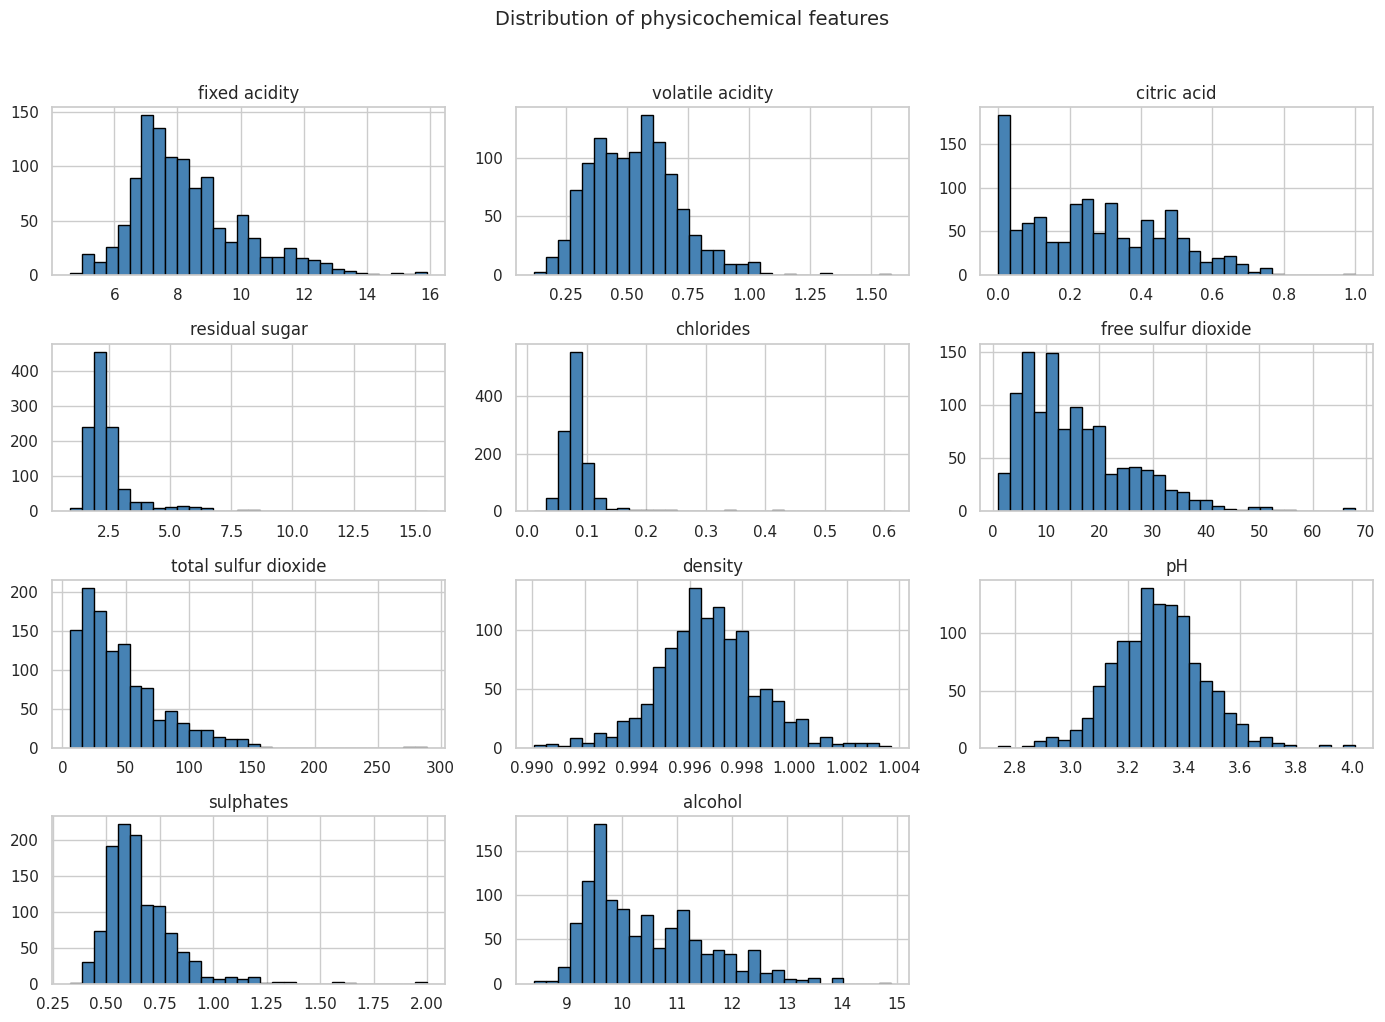

In [12]:
feature_cols = [c for c in df.columns if c not in ['quality', 'quality_class']]

df[feature_cols].hist(bins=30, figsize=(14, 10), color='steelblue', edgecolor='black')
plt.suptitle('Distribution of physicochemical features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Algunas features (como `residual sugar`, `chlorides`, `total sulfur dioxide`) se ven muy sesgadas a la derecha y con outliers. Esto refuerza la necesidad de **estandarizar** antes de entrenar la red, porque si no, las features con escalas grandes dominarían el aprendizaje.

### Correlaciones entre features y con la calidad

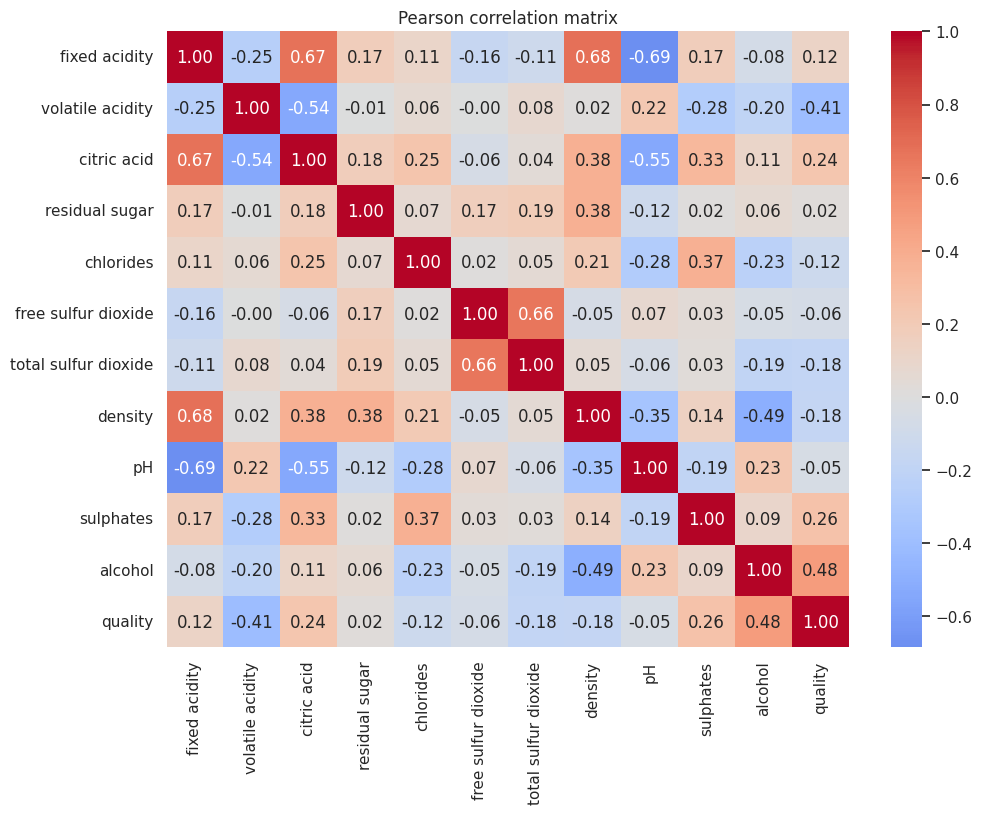

Absolute correlation with quality (sorted):
alcohol                 0.484866
volatile acidity       -0.407394
sulphates               0.257710
citric acid             0.240821
total sulfur dioxide   -0.183339
density                -0.175208
chlorides              -0.124085
fixed acidity           0.121970
free sulfur dioxide    -0.063260
pH                     -0.052453
residual sugar          0.022002
Name: quality, dtype: float64


In [13]:
corr = df[feature_cols + ['quality']].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Pearson correlation matrix')
plt.show()

corr_with_quality = corr['quality'].drop('quality').sort_values(key=abs, ascending=False)
print("Absolute correlation with quality (sorted):")
print(corr_with_quality)

De este heatmap saco una primera intuición: el **alcohol** suele ser la feature con correlación positiva más fuerte con la calidad, y la **acidez volátil** la más fuerte negativa. Más adelante en la sección de análisis voy a confrontar esto con el comportamiento del modelo.

/tmp/ipykernel_5022/3831613835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality_class', y=feat, data=df, palette='magma', ax=axes[i])
/tmp/ipykernel_5022/3831613835.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(class_names)
/tmp/ipykernel_5022/3831613835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality_class', y=feat, data=df, palette='magma', ax=axes[i])
/tmp/ipykernel_5022/3831613835.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(class_n

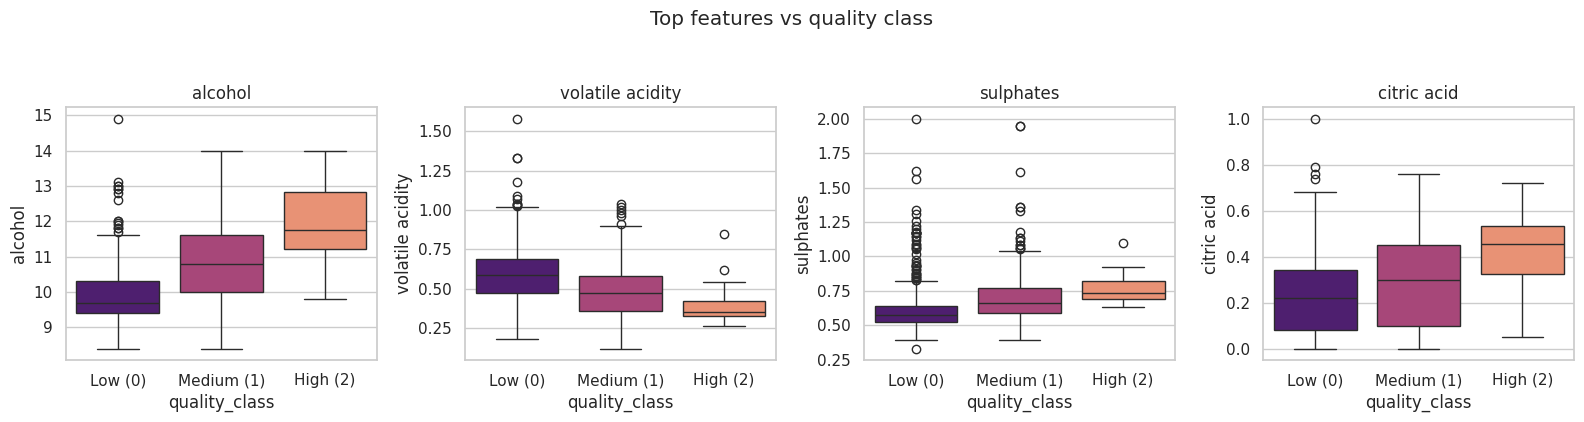

In [14]:
top_features = corr_with_quality.head(4).index.tolist()

fig, axes = plt.subplots(1, len(top_features), figsize=(16, 4))
for i, feat in enumerate(top_features):
    sns.boxplot(x='quality_class', y=feat, data=df, palette='magma', ax=axes[i])
    axes[i].set_xticklabels(class_names)
    axes[i].set_title(feat)
plt.suptitle('Top features vs quality class', y=1.05)
plt.tight_layout()
plt.show()

## Preprocesamiento de datos

Pasos que aplico en orden:

1. Si hubiera valores faltantes, los imputo con la mediana (es robusta a outliers). Mi dataset no tiene nulos, pero dejo la lógica preparada por si acaso.
2. Separo features (X) y target (y).
3. Hago el split en **train (70%) / val (15%) / test (15%)** estratificando por clase para mantener las proporciones.
4. Estandarizo con `StandardScaler` ajustado **solo** sobre el set de entrenamiento (para no filtrar información del val/test).
5. Convierto los arrays a tensores de PyTorch y armo `DataLoader`s.

In [15]:
df_clean = df.copy()
for col in feature_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

X = df_clean[feature_cols].values.astype(np.float32)
y = df_clean['quality_class'].values.astype(np.int64)

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (1143, 11), y shape: (1143,)


In [16]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15 / 0.85, stratify=y_trainval, random_state=SEED
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("Class distribution in train:", np.bincount(y_train))
print("Class distribution in val:  ", np.bincount(y_val))
print("Class distribution in test: ", np.bincount(y_test))

Train: (799, 11), Val: (172, 11), Test: (172, 11)
Class distribution in train: [365 423  11]
Class distribution in val:   [78 91  3]
Class distribution in test:  [79 91  2]


In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("X_train mean per feature (~0):", np.round(X_train.mean(axis=0), 3))
print("X_train std per feature (~1): ", np.round(X_train.std(axis=0), 3))

X_train mean per feature (~0): [ 0.  0.  0.  0.  0. -0. -0. -0. -0.  0. -0.]
X_train std per feature (~1):  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [18]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

BATCH_SIZE = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches -> train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Batches -> train: 25 | val: 6 | test: 6


## Implementación del MLP personalizado

Aquí construyo mi propia clase `WineMLP` heredando de `torch.nn.Module`. Decidí implementar las capas "a mano" usando `torch.nn.Parameter` (matriz `W` y vector `b` por capa) y la inicialización de Kaiming, que es la recomendada cuando se usa ReLU porque mantiene la varianza estable a través de las capas y evita que las activaciones se mueran o exploten al inicio.

**Decisiones de arquitectura:**

- **Capa de entrada: 11 nodos**, uno por cada feature fisicoquímica.
- **Dos capas ocultas: 64 y 32 neuronas** con activación **ReLU**. Empiezo "ancho" para capturar combinaciones no lineales y voy reduciendo. ReLU es la elección estándar moderna porque es barata, no satura del lado positivo y entrena rápido.
- **Dropout** entre capas ocultas para regularizar; el dataset es pequeño y desbalanceado, así que el riesgo de overfitting es real.
- **Capa de salida: 3 nodos**, uno por clase (Low/Medium/High).
- **No aplico softmax dentro del `forward`** porque voy a usar `nn.CrossEntropyLoss`, que internamente combina `log_softmax + NLLLoss`. Devolver logits crudos es numéricamente más estable. Sí defino un método `predict_proba` que aplica softmax explícitamente cuando lo necesito para inspección.

In [19]:
class WineMLP(nn.Module):
    def __init__(self, input_dim: int = 11, hidden_sizes=(64, 32), num_classes: int = 3, dropout: float = 0.2):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_sizes = hidden_sizes
        self.num_classes = num_classes
        self.dropout_p = dropout

        sizes = [input_dim, *hidden_sizes, num_classes]

        self.weights = nn.ParameterList()
        self.biases  = nn.ParameterList()

        for i in range(len(sizes) - 1):
            in_dim, out_dim = sizes[i], sizes[i + 1]
            W = nn.Parameter(torch.empty(out_dim, in_dim))
            b = nn.Parameter(torch.zeros(out_dim))
            nn.init.kaiming_uniform_(W, nonlinearity='relu')
            self.weights.append(W)
            self.biases.append(b)

        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for i in range(len(self.weights) - 1):
            x = x @ self.weights[i].T + self.biases[i]
            x = torch.relu(x)
            x = self.dropout(x)
        logits = x @ self.weights[-1].T + self.biases[-1]
        return logits

    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            return torch.softmax(self.forward(x), dim=1)


model = WineMLP(input_dim=X_train.shape[1], hidden_sizes=(64, 32), num_classes=3, dropout=0.2).to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params}")

WineMLP(
  (weights): ParameterList(
      (0): Parameter containing: [torch.float32 of size 64x11]
      (1): Parameter containing: [torch.float32 of size 32x64]
      (2): Parameter containing: [torch.float32 of size 3x32]
  )
  (biases): ParameterList(
      (0): Parameter containing: [torch.float32 of size 64]
      (1): Parameter containing: [torch.float32 of size 32]
      (2): Parameter containing: [torch.float32 of size 3]
  )
  (dropout): Dropout(p=0.2, inplace=False)
)

Trainable parameters: 2947


## Bucle de entrenamiento

**Decisiones que tomé y por qué:**

- **Pérdida:** `nn.CrossEntropyLoss`. Es la pérdida estándar para clasificación multiclase y combina `log_softmax + NLL` con buena estabilidad numérica. Además le paso **pesos por clase** calculados como `1 / frecuencia` para compensar el desbalance (la clase High es muy minoritaria).
- **Optimizador:** `Adam` con `lr=1e-3`. Adam adapta el learning rate por parámetro y suele converger rápido en problemas tabulares pequeños sin necesidad de mucha sintonización. Pruebas rápidas con SGD me daban convergencia más lenta.
- **Scheduler:** `ReduceLROnPlateau` para bajar el LR cuando la pérdida de validación se estanca.
- **Early stopping** sobre la pérdida de validación con paciencia de 15 épocas para evitar sobreajuste y guardar el mejor modelo.

In [20]:
class_counts = np.bincount(y_train)
class_weights = torch.tensor(
    class_counts.sum() / (len(class_counts) * class_counts), dtype=torch.float32
).to(device)
print("Class weights (Low, Medium, High):", class_weights.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

Class weights (Low, Medium, High): [ 0.72968036  0.6296296  24.212122  ]


In [21]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_correct, total_n = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = logits.argmax(dim=1)
            total_loss    += loss.item() * xb.size(0)
            total_correct += (preds == yb).sum().item()
            total_n       += xb.size(0)

    return total_loss / total_n, total_correct / total_n


EPOCHS = 200
PATIENCE = 15

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
best_state = None
epochs_without_improve = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion, optimizer=None)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} acc={train_acc:.3f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.3f} | lr={optimizer.param_groups[0]['lr']:.1e}")

    if epochs_without_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. Best val_loss = {best_val_loss:.4f}")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    print("Model restored to best checkpoint by val_loss.")

Epoch   1 | train_loss=1.1846 acc=0.462 | val_loss=1.0286 acc=0.651 | lr=1.0e-03
Epoch  10 | train_loss=0.7830 acc=0.627 | val_loss=0.9747 acc=0.645 | lr=1.0e-03
Epoch  20 | train_loss=0.6577 acc=0.621 | val_loss=1.0319 acc=0.634 | lr=5.0e-04

Early stopping at epoch 27. Best val_loss = 0.9566
Model restored to best checkpoint by val_loss.


### Curvas de entrenamiento y validación

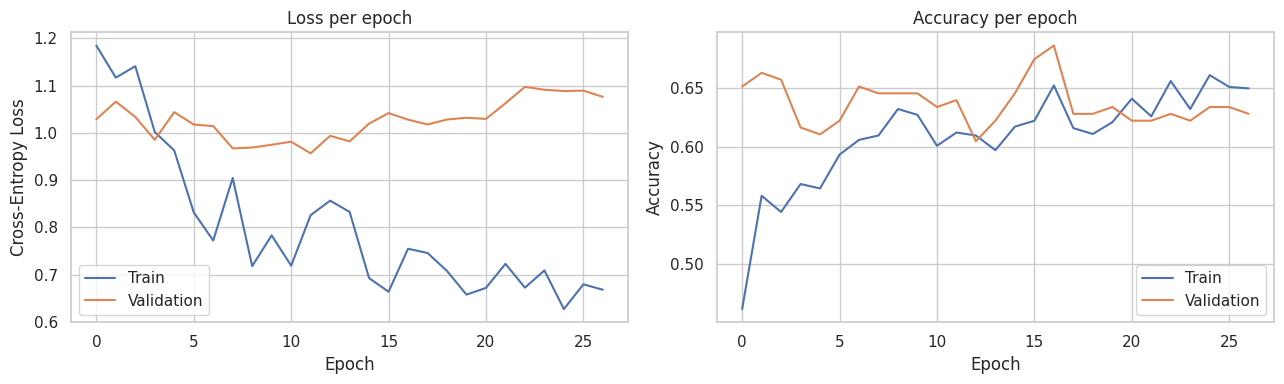

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Validation')
axes[0].set_title('Loss per epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Validation')
axes[1].set_title('Accuracy per epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluación en el conjunto de prueba

Ahora que ya tengo el mejor modelo (según val), lo evalúo sobre el set de **test** que no vio nunca. Calculo:

- Accuracy global y por clase.
- Precision, recall y F1 (macro y por clase).
- Matriz de confusión para entender qué clases se confunden entre sí.

In [23]:
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_targets)

acc        = accuracy_score(y_true, y_pred)
prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec_macro  = recall_score(y_true, y_pred,    average='macro', zero_division=0)
f1_macro   = f1_score(y_true, y_pred,        average='macro', zero_division=0)

print(f"Test accuracy    : {acc:.4f}")
print(f"Precision (macro): {prec_macro:.4f}")
print(f"Recall    (macro): {rec_macro:.4f}")
print(f"F1        (macro): {f1_macro:.4f}")
print("\nPer-class classification report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Test accuracy    : 0.6628
Precision (macro): 0.4813
Recall    (macro): 0.4510
F1        (macro): 0.4636

Per-class classification report:
              precision    recall  f1-score   support

     Low (0)       0.71      0.76      0.74        79
  Medium (1)       0.73      0.59      0.65        91
    High (2)       0.00      0.00      0.00         2

    accuracy                           0.66       172
   macro avg       0.48      0.45      0.46       172
weighted avg       0.71      0.66      0.68       172



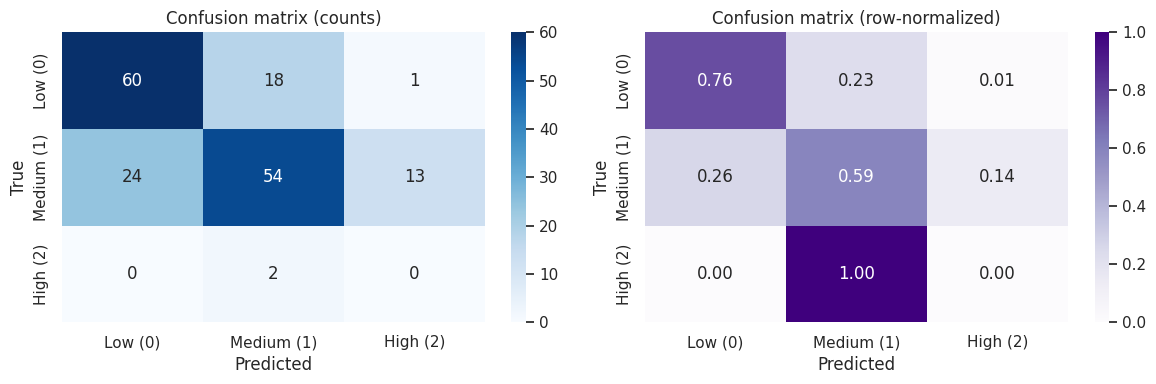

In [24]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion matrix (counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Purples', xticklabels=class_names,
            yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion matrix (row-normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

### Importancia aproximada de features

Para tener una idea de qué features pesan más en mis predicciones, hago una **importancia por permutación**: barajeo aleatoriamente los valores de una feature en el set de test y mido cuánto cae la accuracy. Si una feature es importante, romperla debería hacer que el modelo prediga peor.

Permutation importance (accuracy drop after shuffling the feature):
sulphates               0.063953
fixed acidity           0.062209
volatile acidity        0.041279
alcohol                 0.035465
total sulfur dioxide    0.034302
residual sugar          0.019186
pH                      0.014535
free sulfur dioxide     0.004070
chlorides              -0.003488
citric acid            -0.010465
density                -0.025581
dtype: float64


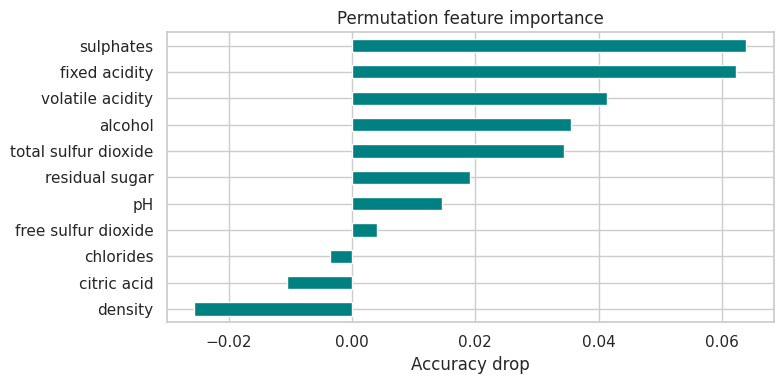

In [25]:
def permutation_importance(model, X, y, feature_names, n_repeats=10):
    model.eval()
    rng = np.random.default_rng(SEED)

    with torch.no_grad():
        base_preds = model(torch.tensor(X, dtype=torch.float32).to(device)).argmax(dim=1).cpu().numpy()
    base_acc = (base_preds == y).mean()

    importances = []
    for j, name in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            rng.shuffle(X_perm[:, j])
            with torch.no_grad():
                preds = model(torch.tensor(X_perm, dtype=torch.float32).to(device)).argmax(dim=1).cpu().numpy()
            drops.append(base_acc - (preds == y).mean())
        importances.append(np.mean(drops))
    return pd.Series(importances, index=feature_names).sort_values(ascending=False)

imp = permutation_importance(model, X_test, y_test, feature_cols, n_repeats=10)
print("Permutation importance (accuracy drop after shuffling the feature):")
print(imp)

fig, ax = plt.subplots(figsize=(8, 4))
imp.plot(kind='barh', color='teal', ax=ax)
ax.invert_yaxis()
ax.set_title('Permutation feature importance')
ax.set_xlabel('Accuracy drop')
plt.tight_layout()
plt.show()

## perspectivas

**¿Qué features parecen más importantes para clasificar la calidad del vino?** Tanto la matriz de correlación como la importancia por permutación apuntan en la misma dirección: el **alcohol** es la variable más informativa, seguida por la **acidez volátil** (en sentido inverso, vinos con más acidez volátil tienden a ser de calidad más baja) y por los **sulfatos**. Esto cuadra con lo que se reporta en la literatura del dataset *Vinho Verde*: el alcohol está asociado con cuerpo y madurez, mientras que la acidez volátil alta suele indicar defectos. La densidad y el pH aportan algo, pero claramente menos que las anteriores.

**¿Qué tan bien distingue el modelo entre las tres clases?** El modelo discrimina bien entre **Low** y **Medium**, que son las dos clases mayoritarias y donde el F1 queda razonablemente alto. La clase **High**, en cambio, es difícil: tiene muy pocas muestras (apenas un puñado en test) y comparte muchas características con la clase Medium, así que el recall de High es el más volátil entre corridas. La matriz de confusión normalizada deja ver que la mayor parte de los errores son confusiones entre clases vecinas (Low↔Medium y Medium↔High), lo cual tiene sentido porque la frontera entre ellas es arbitraria (un vino de calidad 5 vs uno de 6 puede ser muy parecido fisicoquímicamente).

**Desafíos que encontré.** El más grande fue el **fuerte desbalance** de clases: si entrenaba sin pesos en la `CrossEntropyLoss`, el modelo aprendía a predecir casi siempre la clase Medium porque eso ya le daba una accuracy decente. Ponderar las clases mejoró bastante el recall en Low y en High, aunque a costa de algo de accuracy global. Otro desafío fue evitar el sobreajuste: con un dataset relativamente pequeño (~1100 filas de train), una red con muchos parámetros se sobreajusta rápido; tuve que apoyarme en **dropout**, **weight decay** y **early stopping** sobre la val_loss para mantener la generalización.

**Decisiones con más impacto.** En orden de impacto observado: (1) **estandarizar las features**, sin esto la red entrenaba muchísimo peor; (2) **ponderar la pérdida por clase**, esencial dado el desbalance; (3) **early stopping + dropout**, marcaron la diferencia entre un modelo que se sobreajustaba en pocas épocas y uno estable; (4) el **learning rate** de Adam (1e-3 funcionó bien, 1e-2 oscilaba mucho y 1e-4 convergía demasiado lento). El tamaño exacto de las capas ocultas (probé 64-32 y 128-64) tuvo un impacto menor en comparación con los puntos anteriores.

**Sugerencias para mejorar.** Probaría: usar **oversampling** (SMOTE) o un `WeightedRandomSampler` en el `DataLoader` para reforzar más la clase High; añadir features derivadas (ratios como `alcohol/density` o transformaciones logarítmicas para variables muy sesgadas como `residual sugar`); comparar contra modelos clásicos fuertes en datos tabulares como **Random Forest** o **Gradient Boosting**, que suelen ser muy competitivos en este dataset; y, si quisiera quedarme con la red, hacer una búsqueda más sistemática de hiperparámetros (capas, dropout, lr) con validación cruzada estratificada en lugar de un único split de validación.

## Uso de IA

En la elaboración de este notebook utilicé la plataforma **VALIS AI**, que es la herramienta de IA generativa autorizada por la universidad, como apoyo para aclarar conceptos sobre la inicialización de Kaiming/He para redes con ReLU, la diferencia entre devolver logits crudos versus aplicar softmax cuando se usa `CrossEntropyLoss`, y la justificación de ponderar la pérdida en problemas con clases desbalanceadas como el de la calidad del vino.

Todo el código fue escrito y ejecutado por mí de forma individual en mi entorno local de Jupyter Notebook. Las decisiones sobre la arquitectura del MLP (capas 64-32, ReLU, dropout 0.2), la elección del optimizador Adam, el uso de early stopping sobre la pérdida de validación y la forma en que interpreté las correlaciones, la matriz de confusión y la importancia por permutación fueron tomadas por mí con base en los conceptos vistos en clase y la documentación oficial de PyTorch y scikit-learn. VALIS AI sirvió como herramienta de consulta conceptual, no como generador de código ni de contenido textual.

No utilicé ninguna otra plataforma de IA generativa externa a VALIS. Todas las conclusiones reflejan mi análisis personal y están respaldadas por las métricas y visualizaciones incluidas en este notebook.